In [12]:
import librosa
from os import path

SOURCE_PATH = path.normpath("../validations/")

# Least audio duration
AUDIO_SAMPLE_RATE = 44_100 # Hz

# How many frames to skip in each samples
CQT_HOP_LENGTH = 512

# Bin numbers based on octaves for input
CQT_OCTAVES = 6
CQT_BINS_PER_OCTAVE = 36

# Starts from note
CQT_FMIN = librosa.note_to_hz('C1')

print({
  "feature bins": CQT_BINS_PER_OCTAVE * CQT_OCTAVES,
  "feature start Hz": CQT_FMIN,
})

{'feature bins': 216, 'feature start Hz': 32.70319566257483}


In [14]:
from os import listdir, path
from tqdm.notebook import tqdm
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

def target_npz_path(dataset_name):
    return path.join(SOURCE_PATH, f"{dataset_name}.npz")

def extract_cqt_features(audio_path):
    """Extracts raw CQT features from an audio file."""
    try:
        y, sr = librosa.load(audio_path, sr=AUDIO_SAMPLE_RATE)
        cqt = librosa.cqt(
            y=y,
            sr=sr,
            fmin=CQT_FMIN,
            n_bins=CQT_BINS_PER_OCTAVE * CQT_OCTAVES,
            bins_per_octave=CQT_BINS_PER_OCTAVE,
            hop_length=CQT_HOP_LENGTH,
            window='hann',
        )
        return np.abs(cqt)
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

for dataset_name in tqdm(listdir(SOURCE_PATH), desc="Processing validation sets"):
    dataset_path = path.join(SOURCE_PATH, dataset_name)
    if not path.isdir(dataset_path):
        continue

    features = []
    labels = []

    for file_name in tqdm(listdir(dataset_path), desc=f"Processing {dataset_name}"):
        audio_path = path.join(dataset_path, file_name)
        if not path.isfile(audio_path) or not file_name.lower().endswith(".wav"):
            continue

        cqt = extract_cqt_features(audio_path)
        if cqt is not None:
            features.append(cqt)
            labels.append(dataset_name)

    npz_path = target_npz_path(dataset_name)
    features_array = np.empty(len(features), dtype=object)
    features_array[:] = features
    labels = np.array(labels)
    np.savez(npz_path, features=features_array, labels=labels)
    print(f"Saved {len(features)} raw CQT features to {npz_path}")
    print(f"Shape of labels: {labels.shape}")

Processing validation sets:   0%|          | 0/4 [00:00<?, ?it/s]

Processing major_only:   0%|          | 0/20 [00:00<?, ?it/s]

Saved 10 raw CQT features to ../validations/major_only.npz
Shape of labels: (10,)


Processing sustain_delay:   0%|          | 0/40 [00:00<?, ?it/s]

Saved 20 raw CQT features to ../validations/sustain_delay.npz
Shape of labels: (20,)


Processing no_sustain_no_delay:   0%|          | 0/64 [00:00<?, ?it/s]

Saved 32 raw CQT features to ../validations/no_sustain_no_delay.npz
Shape of labels: (32,)


Processing sustain_no_delay:   0%|          | 0/20 [00:00<?, ?it/s]

Saved 10 raw CQT features to ../validations/sustain_no_delay.npz
Shape of labels: (10,)


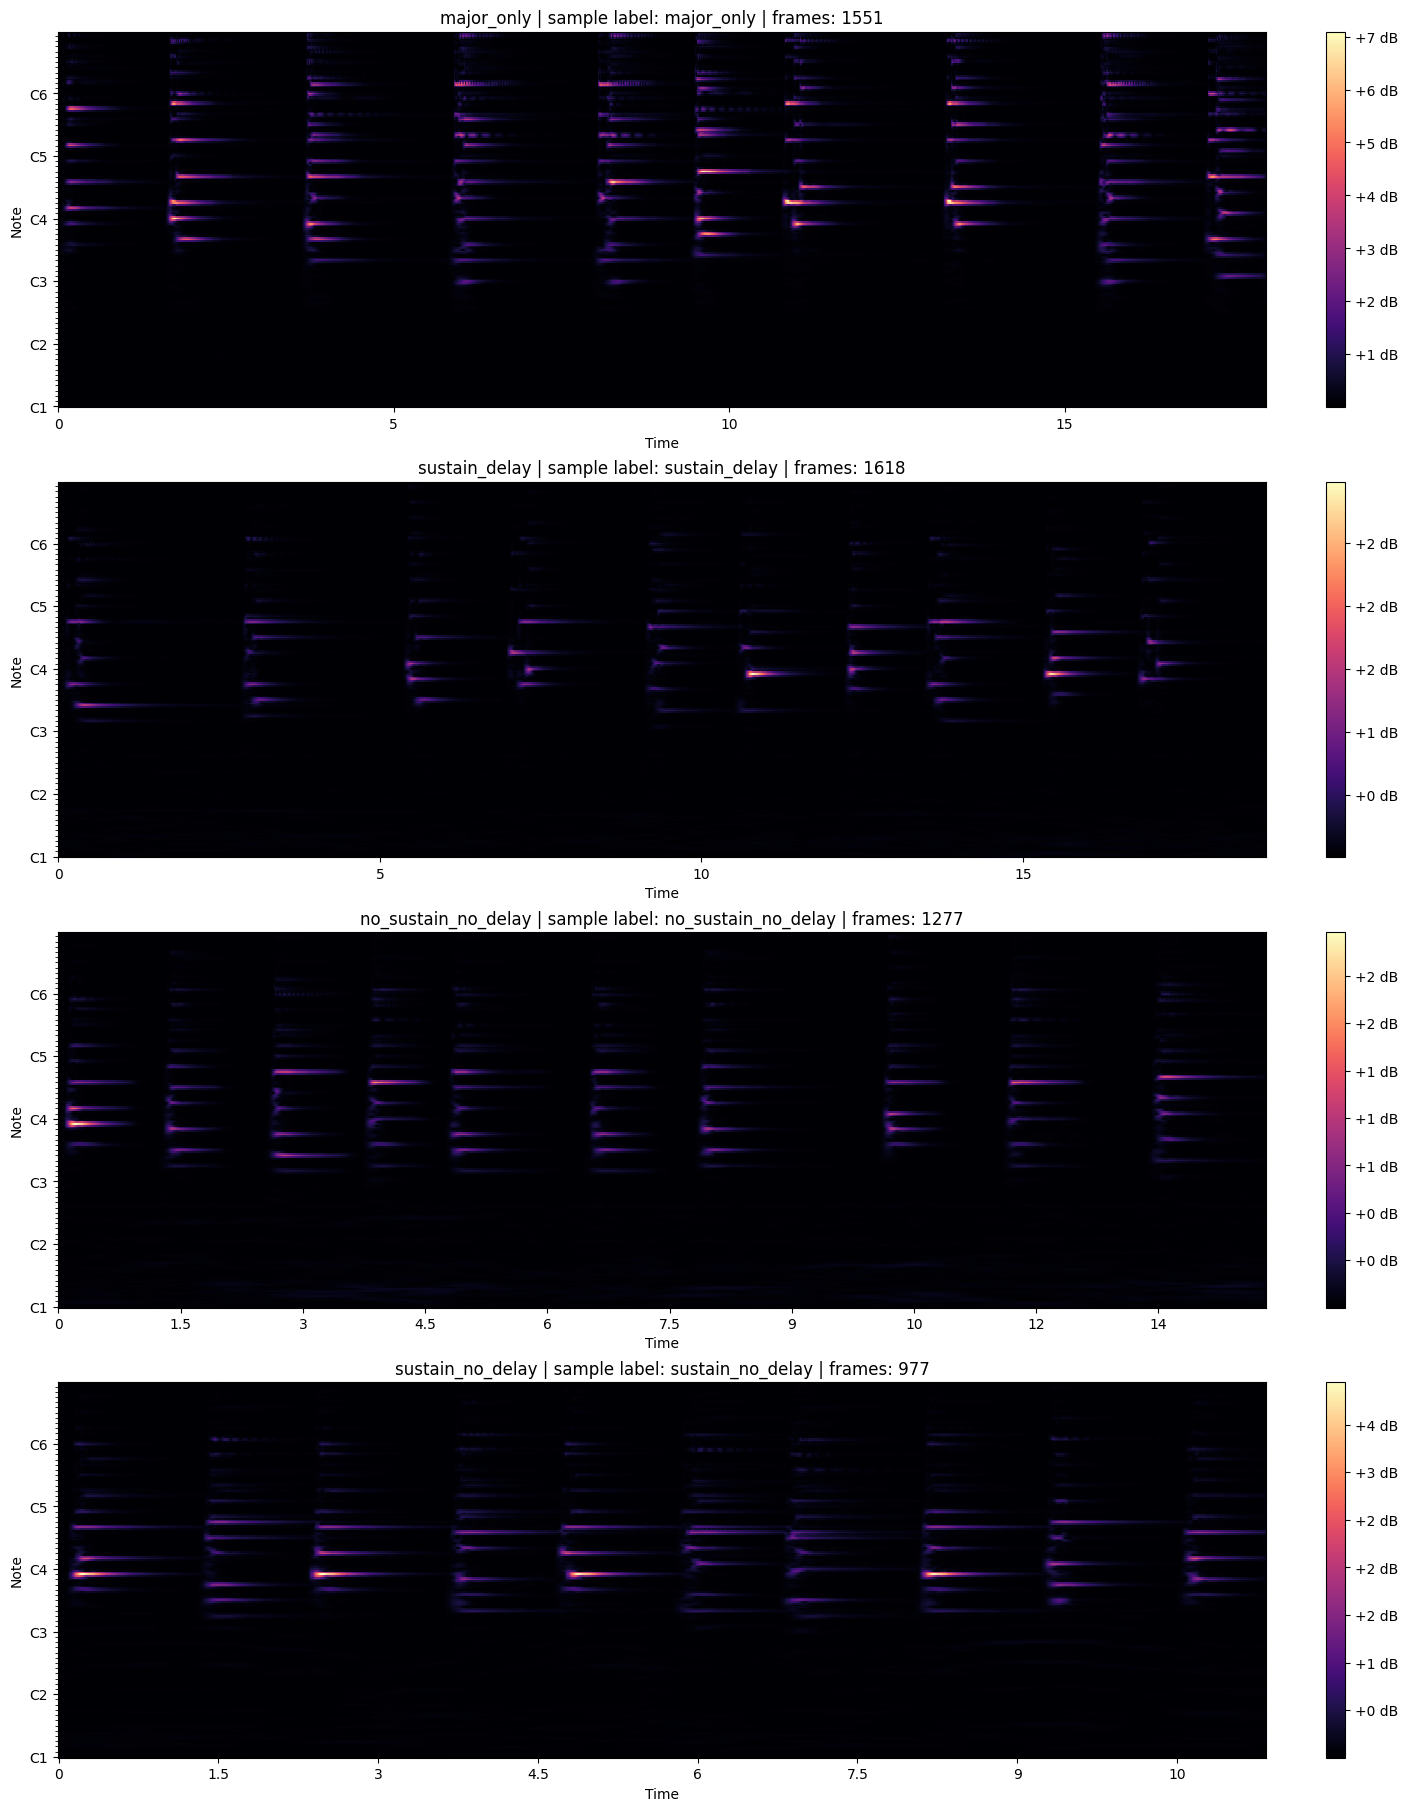

In [15]:
import matplotlib.pyplot as plt
import librosa.display

validation_datasets = [
    "major_only",
    "sustain_delay",
    "no_sustain_no_delay",
    "sustain_no_delay",
]

fig, axes = plt.subplots(len(validation_datasets), 1, figsize=(14, 18), constrained_layout=True)

if len(validation_datasets) == 1:
    axes = [axes]

for axis, dataset_name in zip(axes, validation_datasets):
    npz_path = target_npz_path(dataset_name)
    data = np.load(npz_path, allow_pickle=True)
    features = data["features"]
    labels = data["labels"]

    sample_cqt = features[0]
    librosa.display.specshow(
        sample_cqt,
        x_axis='time',
        y_axis='cqt_note',
        sr=AUDIO_SAMPLE_RATE,
        hop_length=CQT_HOP_LENGTH,
        fmin=CQT_FMIN,
        bins_per_octave=CQT_BINS_PER_OCTAVE,
        ax=axis,
    )
    axis.set_title(f"{dataset_name} | sample label: {labels[0]} | frames: {sample_cqt.shape[1]}")
    fig.colorbar(axis.collections[0], ax=axis, format="%+2.0f dB")

plt.show()